In [108]:
import os
import pandas as pd

path_train = os.path.dirname(os.getcwd() ) + '/history_data/tw/value_invest/top200.xls'
path_test = os.path.dirname(os.getcwd() ) + '/history_data/tw/value_invest/top200_testing.xlsx'

# 確認xlsx檔案是否存在
if os.path.exists(path_train):
    df_train = pd.read_excel(path_train)
    print("xlsx 檔案已成功讀取")
else:
    print(f"檔案不存在: {path_train}")

# 確認xls檔案是否存在
if os.path.exists(path_test):
    df_test = pd.read_excel(path_test)
    print("xls 檔案已成功讀取")
else:
    print(f"檔案不存在: {path_test}")

columns_to_keep = ['證券代碼', '簡稱', '年月', '市值(百萬元)', '收盤價(元)_年', "股價淨值比",'資產報酬率ROA', 'Return']
df_train = df_train[columns_to_keep]
df_test = df_test[columns_to_keep]
print(df_train)
print(df_test)


xlsx 檔案已成功讀取
xls 檔案已成功讀取
          證券代碼           簡稱      年月  市值(百萬元)  收盤價(元)_年    股價淨值比  資產報酬率ROA  \
0     19972330   台積電         199712   457105     15.24  0.89594  0.223790   
1         2303  聯電           199712   263536     20.55  1.27240  0.145880   
2         2002  中鋼           199712   181781      5.53  0.35770  0.136380   
3         1303  南亞           199712   175637     14.81  0.74949  0.099458   
4         2357  華碩           199712   166991    158.47  2.59620  0.356970   
...        ...          ...     ...      ...       ...      ...       ...   
2595      2107  厚生           200912    14782     27.90  1.64020  0.130750   
2596      5534  長虹           200912    14688     59.85  2.14750  0.187880   
2597      3014  聯陽           200912    14621     69.66  2.23840  0.078390   
2598      2511  太子           200912    14608     15.25  1.27720  0.051981   
2599      8213  志超           200912    14607     66.65  2.80040  0.175820   

        Return  
0      -6.3648  
1     -18.0049  

In [109]:
import pandas as pd

# 假設 df_train 已經讀取並包含必要的欄位
# 提取年份資訊
df_train['年份'] = df_train['年月'].astype(str).str[:4]
df_test['年份'] = df_test['年月'].astype(str).str[:4]
# 剔除年份是2009的資料
df_train = df_train[df_train['年份'] != '2009']

# 合併訓練和測試數據
all_data = pd.concat([df_train, df_test])
# print(all_data)

# 按年份分組數據
groups = all_data.groupby('年份')

# 初始化結果列表
top_stocks_list = []
annual_returns_list = []

# 對每年的資料進行處理
for year, group in groups:
    print(f"處理年份: {year}")

    # 對指定欄位進行排序並給予權重，淨值比越小越高，ROA越大越高
    group['淨值比_權重'] = group['股價淨值比'].rank(ascending=False)
    group['ROA_權重'] = group['資產報酬率ROA'].rank(ascending=True)
    
    # 計算加權分數
    group['加權分數'] = group[['淨值比_權重', 'ROA_權重']].sum(axis=1)
    # print(group[['股價淨值比','淨值比_權重']])
    # print(group[['資產報酬率ROA','ROA_權重']])

    # 依照加權分數選出10隻股票
    top_stocks = group.nlargest (10, '加權分數')
    top_stocks_list.append(top_stocks)

    # 計算每年的總報酬率
    annual_return = top_stocks['Return'].mean()
    annual_returns_list.append({'年份': year, '總報酬率': annual_return})

    print("加權分數最好的10隻股票和總報酬率")
    print(top_stocks[["簡稱", "Return"]])
    print(f"總報酬率: {annual_return}%")
    print()


# 合併結果
annual_returns = pd.DataFrame(annual_returns_list)

# 計算累積總報酬率，標籤用年分
annual_returns['累積總報酬率'] = (annual_returns['總報酬率'] * 0.01 + 1).cumprod()
cumulative_returns = annual_returns.set_index('年份')['累積總報酬率']

print("累積總報酬率")
print(cumulative_returns)


處理年份: 1997
加權分數最好的10隻股票和總報酬率
              簡稱    Return
10   鴻海            54.5701
103  D 復盛          -8.6990
114  豐泰            -9.4761
34   中環            25.1898
51   聯強            46.0888
2    中鋼            -9.2224
12    英業達          42.6763
75   長興           -18.1818
170  敬鵬             3.3943
180  精業           120.0200
總報酬率: 24.636000000000003%

處理年份: 1998
加權分數最好的10隻股票和總報酬率
              簡稱   Return
360  金緯          -98.9775
378  力麒          -49.0651
224  寶成           25.5390
211  仁寶           39.4893
203  中鋼           39.6414
388   中興電         -3.1348
205  鴻海           87.7049
279  長興            8.2305
212  台化           53.7123
302  D 復盛        -24.7892
總報酬率: 7.83508%

處理年份: 1999
加權分數最好的10隻股票和總報酬率
              簡稱   Return
536  中鼎          -24.6359
449  萬海           -4.4390
589   中興電        -22.0065
517  可成          -75.0269
410  中鋼           -6.8474
583  巨大           58.8640
585  冠德          -47.9762
464  正新          -13.8482
574  漢唐          -55.5268
580  瑞軒          -50.4371
總

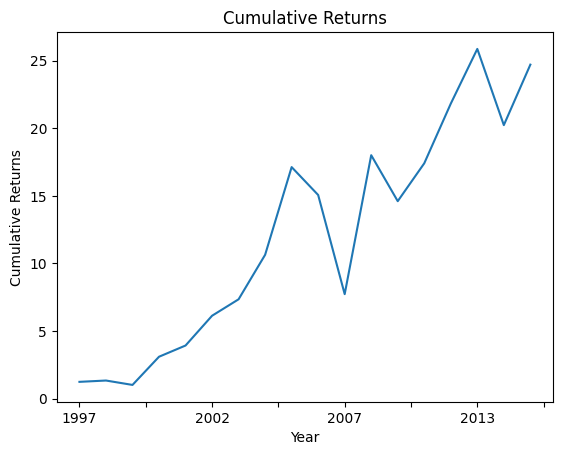

In [110]:
import matplotlib.pyplot as plt

# 繪製累積總報酬率圖表
cumulative_returns.plot()
plt.title('Cumulative Returns')
plt.xlabel('Year')
plt.ylabel('Cumulative Returns')
plt.show()

